# Physics-Informed Neural Networks (PINN) for the Shrinking Core Model

This notebook demonstrates the implementation of a PINN to solve the **Shrinking Core Model**, a fundamental kinetic model in chemical engineering describing solid-gas reactions.

### **Problem Statement**
The fractional conversion $X$ of a solid particle over time $t$ is governed by the ODE:
$$\frac{dX}{dt} = k(1-X)^{2/3}$$

**Parameters:**
- Rate constant $k = 0.15 \, s^{-1}$
- Initial condition $X(0) = 0$
- Time domain $t \in [0, 3/k]$

**Analytical Solution:**
$$X(t) = 1 - (1 - \frac{kt}{3})^3$$

# **DeepXDE Implementation**

## **Approach 1: High-level Implementation with DeepXDE**
DeepXDE is a popular library for PINNs. We use the TensorFlow backend here to define the geometry, PDE, and boundary conditions.

In [ ]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.7 MB/s eta 0:00:00


In [ ]:
# import libraries
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt


No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
# Defining the parameters
k = 0.15    # Unit: s^-1
X_0 = 0.0   # Initial conversion

In [ ]:
# Defining the computational domain
timedomain = dde.geometry.TimeDomain(0, 3/k)

In [ ]:
# Defining the pde with numerical stability for the (1-x) term
def pde(t, x):
    dx_dt = dde.grad.jacobian(x, t, i=0)
    # Use dde.backend.abs and a small epsilon to prevent gradient issues at x=1
    res = dx_dt - k * dde.backend.pow(dde.backend.abs(1 - x) + 1e-9, 2/3)
    return res

In [ ]:
# Defining the analytical solution
def func(t):
  return 1- (1-k*t/3)**3

In [ ]:
# Defining the boundary conditions
def boundary(_, on_initial):
  return on_initial

ic = dde.icbc.IC(timedomain, lambda x: X_0, boundary, component=0)

In [ ]:
# Redefining the problem to pick up the new pde function
data = dde.data.TimePDE(timedomain, pde, ic, num_domain=500, num_boundary=10, solution=func, num_test=1000)

In [ ]:
# Defining the neural network
layer_size = [1] + [60] * 3 + [1]
activation = "tanh"
initializer = "Glorot normal"
net = dde.nn.FNN(layer_size, activation, initializer)

In [ ]:
# 1. Re-initialize the network to clear NaN weights
net = dde.nn.FNN(layer_size, activation, initializer)

# 2. Re-initialize and train the model with the updated PDE and fresh weights
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[1, 1])
losshistory, train_state = model.train(iterations=2000)

Compiling model...
'compile' took 0.005198 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [2.82e-03, 0.00e+00]    [2.76e-03, 0.00e+00]    [1.79e-01]    
1000      [4.86e-06, 6.11e-08]    [4.89e-06, 6.11e-08]    [7.94e-03]    
2000      [2.66e-06, 1.10e-08]    [2.64e-06, 1.10e-08]    [6.21e-03]    

Best model at step 2000:
  train loss: 2.67e-06
  test loss: 2.65e-06
  test metric: [6.21e-03]

'train' took 12.863258 s



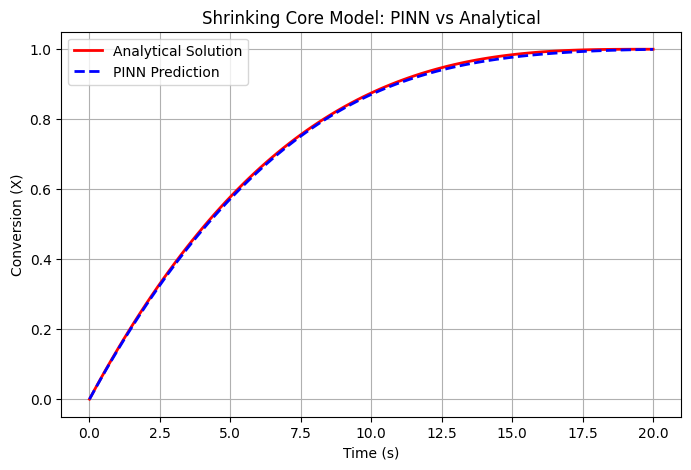

In [ ]:
# Visualization of the results
t_eval = np.linspace(0, 3/k, 100).reshape(-1, 1)
X_pred = model.predict(t_eval)
X_true = func(t_eval)

plt.figure(figsize=(8, 5))
plt.plot(t_eval, X_true, 'r-', label='Analytical Solution', linewidth=2)
plt.plot(t_eval, X_pred, 'b--', label='PINN Prediction', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Conversion (X)')
plt.title('Shrinking Core Model: PINN vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

### **Derivative Verification**
To verify the kinetics, we extract the derivative $dX/dt$ from the neural network and compare it with the analytical derivative.

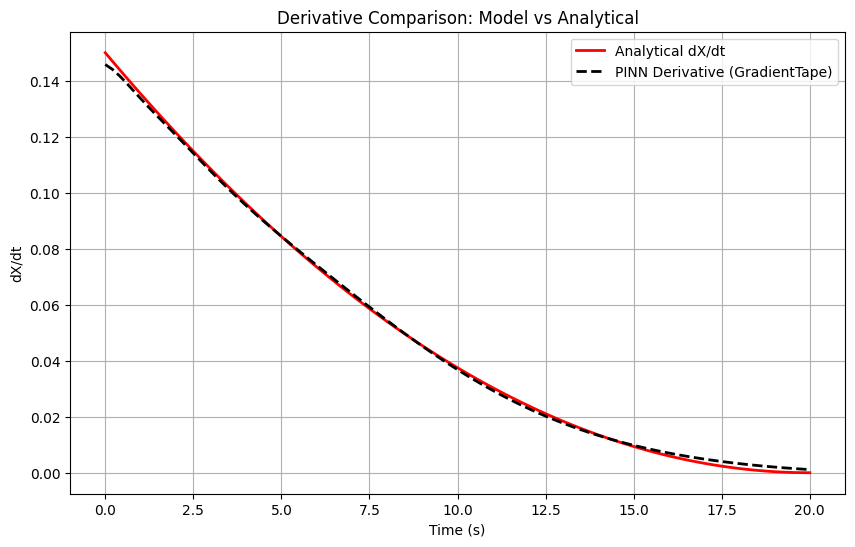

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare input as a tensor and enable gradient tracking
t_eval_tensor = tf.convert_to_tensor(t_eval, dtype=tf.float32)

# 2. Use GradientTape to compute the derivative dX/dt
# This is the reliable way to get derivatives from the model net in eager mode
with tf.GradientTape() as tape:
    tape.watch(t_eval_tensor)
    X_pred_tensor = model.net(t_eval_tensor)

dX_dt_pred = tape.gradient(X_pred_tensor, t_eval_tensor).numpy()

# 3. Calculate analytical values for comparison
X_true = func(t_eval)
dX_dt_true = k * (1 - X_true)**(2/3)

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(t_eval, dX_dt_true, 'r-', label='Analytical dX/dt', linewidth=2)
plt.plot(t_eval, dX_dt_pred, 'k--', label='PINN Derivative (GradientTape)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('dX/dt')
plt.title('Derivative Comparison: Model vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

# **Pytorch Implementation**

## **Approach 2: Custom PINN Implementation with PyTorch**
In this section, we implement the PINN from scratch using pure PyTorch. This provides more control over the training loop and loss weight balancing.

In [ ]:
# importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Defining the neural network
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(1, 50)
    self.fc2 = nn.Linear(50, 50)
    self.fc3 = nn.Linear(50, 1)

  def forward(self, x):
    a1 = F.tanh(self.fc1(x))
    a2 = F.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=1, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=1, bias=True)
)


In [ ]:
# Defining the parameters
k = 0.15    # Unit: s^-1
X_0 = 0.0   # Initial conversion

In [ ]:
# Defining the pde
def pde(net, t):
  x = net(t)
  dx_dt = torch.autograd.grad(x, t, torch.ones_like(t), create_graph=True)[0]
  pde_res = dx_dt - k*(abs(1-x+1e-9)**(2/3))
  return pde_res

In [ ]:
# Defining the loss
def compute_loss(net, t, t_ic, x_ic):
  mse_loss = nn.MSELoss()

  # PDE Loss
  pde_res = pde(net, t)
  pde_loss = mse_loss(pde_res, torch.zeros_like(pde_res))

  # IC Loss
  ic_pred = net(t_ic)
  ic_loss = mse_loss(ic_pred, x_ic)

  # Total Loss
  total_loss = pde_loss + ic_loss
  return total_loss, pde_loss, ic_loss

In [ ]:
# Collocation points
t = torch.linspace(0, 3/k, 500).reshape(-1, 1).requires_grad_(True)

# Initial collocation points
t_ic = torch.zeros(10, 1)
x_ic = torch.zeros(10, 1)

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(net.parameters(), lr=0.001)
epochs = 5000

# Storing all losses
total_loss, pde_loss, ic_loss = [], [], []

for epoch in range(epochs+1):
  optimizer.zero_grad()
  loss_val, pde_val, ic_val = compute_loss(net, t, t_ic, x_ic)
  loss_val.backward()
  optimizer.step()

  # Appending the losses to the lists
  total_loss.append(loss_val.item())
  pde_loss.append(pde_val.item())
  ic_loss.append(ic_val.item())

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Total Loss: {loss_val.item(): .4e}, PDE Loss: {pde_val.item(): .4e}, IC Loss: {ic_val.item(): .4e}")

Epoch 0, Total Loss:  2.8175e-02, PDE Loss:  2.7025e-02, IC Loss:  1.1499e-03
Epoch 100, Total Loss:  1.1199e-05, PDE Loss:  1.1195e-05, IC Loss:  3.5403e-09
Epoch 200, Total Loss:  5.9461e-06, PDE Loss:  5.9457e-06, IC Loss:  4.5660e-10
Epoch 300, Total Loss:  4.6522e-06, PDE Loss:  4.6521e-06, IC Loss:  8.8130e-11
Epoch 400, Total Loss:  4.1346e-06, PDE Loss:  4.1346e-06, IC Loss:  1.5297e-12
Epoch 500, Total Loss:  3.8342e-06, PDE Loss:  3.8342e-06, IC Loss:  4.2404e-11
Epoch 600, Total Loss:  3.6109e-06, PDE Loss:  3.6095e-06, IC Loss:  1.4597e-09
Epoch 700, Total Loss:  3.5338e-06, PDE Loss:  3.5320e-06, IC Loss:  1.8700e-09
Epoch 800, Total Loss:  3.7316e-05, PDE Loss:  3.5066e-06, IC Loss:  3.3809e-05
Epoch 900, Total Loss:  4.3200e-06, PDE Loss:  3.1973e-06, IC Loss:  1.1226e-06
Epoch 1000, Total Loss:  4.0376e-05, PDE Loss:  3.2183e-06, IC Loss:  3.7158e-05
Epoch 1100, Total Loss:  1.5467e-05, PDE Loss:  3.0116e-06, IC Loss:  1.2456e-05
Epoch 1200, Total Loss:  5.9294e-05, PDE

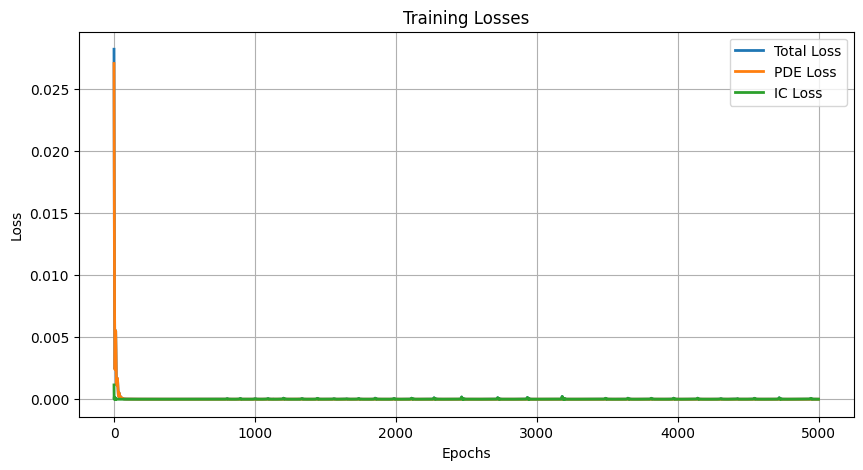

In [ ]:
# plotting the losses
plt.figure(figsize=(10, 5))
plt.plot(total_loss, label='Total Loss', linewidth=2)
plt.plot(pde_loss, label='PDE Loss', linewidth=2)
plt.plot(ic_loss, label='IC Loss', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)
plt.show()

### **Results Visualization**
Finally, we evaluate the trained PyTorch model and visualize the conversion profile against the analytical solution.

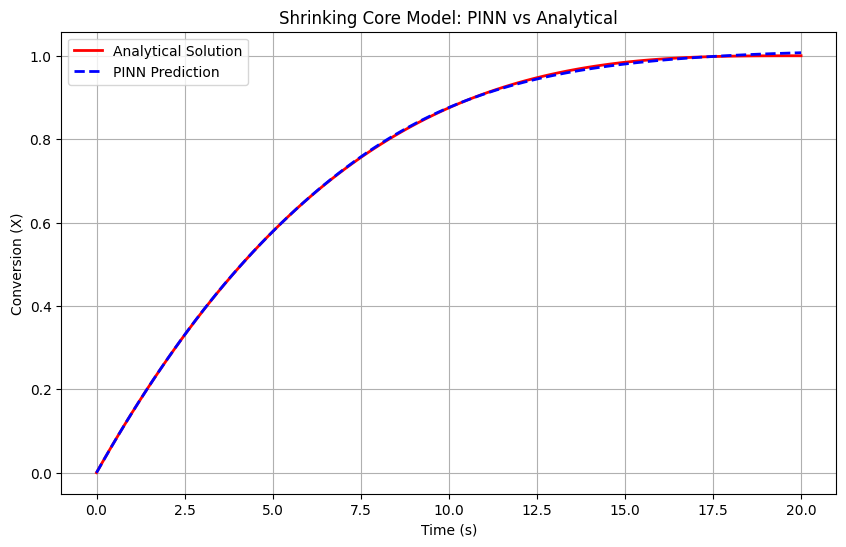

In [ ]:
# Plotting the comparison of results PINNS and analytical
with torch.no_grad():
  t_eval = torch.linspace(0, 3/k, 100).reshape(-1, 1)
  x_pred_pytorch = net(t_eval).numpy()

t_plot = np.linspace(0, 3/k, 100).reshape(-1, 1)
x_plot = func(t_plot)

plt.figure(figsize=(10, 6))
plt.plot(t_plot, x_plot, 'r-', label='Analytical Solution', linewidth=2)
plt.plot(t_eval, x_pred_pytorch, 'b--', label='PINN Prediction', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Conversion (X)')
plt.title('Shrinking Core Model: PINN vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

## **Key Learnings and Technical Insights**

Through the implementation of the Shrinking Core Model using PINNs, several critical technical lessons were identified:

1.  **Numerical Stability of Fractional Powers**: The term $(1-X)^{2/3}$ is sensitive. If the Neural Network predicts $X > 1$ during the early stages of training, the base becomes negative, leading to `NaN` gradients. Using `abs(1 - x) + 1e-9` ensures the model remains numerically stable.

2.  **Handling Training Failures (NaNs)**: Once a model produces `NaN` weights during an iteration, the optimizer cannot recover. It is essential to re-initialize the network weights (`net` object) before restarting the training process.

3.  **Backend-Specific Derivative Extraction**: While DeepXDE provides high-level operators like `dde.grad.jacobian`, extracting derivatives for manual plotting in TensorFlow 2.x environments often requires `tf.GradientTape` due to the library's default eager execution mode.

4.  **Model Flexibility**: Both high-level libraries (DeepXDE) and custom implementations (PyTorch) successfully converged to the analytical solution, demonstrating that PINNs are robust tools for solving chemical kinetic ODEs even with non-linear terms.